# 1. Import Library and setup config

In [61]:
import os, json, warnings
warnings.filterwarnings("ignore")

from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.sql.functions import col, mean, count, when, round as spark_round
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml.clustering import KMeans, BisectingKMeans, GaussianMixture
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

import mlflow
import mlflow.spark

import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt

# Configuration Section

# Name of the MLflow experiment to log runs and results
MLFLOW_EXPERIMENT = "Spotify_Music_Clustering"

# Path to the cleaned Spotify dataset
DATA_PATH = "data/2025_spotify_songs_cleaned.csv"

# Random seed for reproducibility
SEED = 42

# Number of folds used for cross-validation
NUM_FOLDS = 5

# Range of cluster numbers (k) to test
K_RANGE = [3, 4, 5, 6]

# Number of samples to take from the dataset for faster experimentation
# SAMPLE_SIZE = 8000

# Spark & MLflow Initialization

# Initialize SparkSession with sufficient memory for clustering computations
spark = SparkSession.builder.appName("MusicClustering").config("spark.driver.memory", "16g").getOrCreate()

# Set or create the MLflow experiment for tracking results
mlflow.set_experiment(MLFLOW_EXPERIMENT)


2025/10/20 12:35:31 INFO mlflow.tracking.fluent: Experiment with name 'Spotify_Music_Clustering' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///home/dataguy/Documents/Vibe.Coding/Spotify-music-trend-prediction/mlruns/631999068644276573', creation_time=1760938531263, experiment_id='631999068644276573', last_update_time=1760938531263, lifecycle_stage='active', name='Spotify_Music_Clustering', tags={}>

# 2. Read data

In [62]:
spotify_data = (spark.read
                  .option("header", "true")
                  .option("inferSchema", "true")
                  .option("quote", "\"")
                  .option("escape", "\"")
                  .option("encoding", "UTF-8")
                  .option("multiLine", "true")
                  .csv(DATA_PATH))
spotify_data.show(5)

print(f"Number of record: {spotify_data.count()}")


+--------------------+--------------------+--------------------+----------+--------------+---------------+-------+-------------+----------+-----------+-----------+--------------------+------------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+--------------+
|          spotify_id|                name|             artists|daily_rank|daily_movement|weekly_movement|country|snapshot_date|popularity|is_explicit|duration_ms|          album_name|album_release_date|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|time_signature|
+--------------------+--------------------+--------------------+----------+--------------+---------------+-------+-------------+----------+-----------+-----------+--------------------+------------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+--------------+
|7c5uGV9Rys18JP257...|      

[Stage 12039:>                                                      (0 + 1) / 1]

Number of record: 547108


# 3. Data preprocessing

In [63]:
numerical_cols = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'
]

# Categorical musical attributes (discrete types)
categorical_cols = ['key', 'mode', 'time_signature']

all_feature_cols = numerical_cols + categorical_cols

df_raw_features = spotify_data.select("spotify_id", *all_feature_cols).na.drop()


# Convert categorical columns into numerical indices
indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_indexed", handleInvalid="skip")
    for c in categorical_cols
]

# encoding to represent categories as binary vectors
encoders = [
    OneHotEncoder(inputCol=c + "_indexed", outputCol=c + "_encoded")
    for c in categorical_cols
]


final_feature_list = numerical_cols + [c + "_encoded" for c in categorical_cols]

assembler = VectorAssembler(inputCols=final_feature_list, outputCol="raw_features")


# Normalize features to have unit standard deviation
scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="scaled_features",
    withStd=True,
    withMean=False
)


# Create a reusable data preprocessing pipeline
preprocessing_pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler])

scaler_model = preprocessing_pipeline.fit(df_raw_features)
df_processed = scaler_model.transform(df_raw_features).cache()

print("Preprocessing completed. Data is now standardized (scaled_features).")


# Split dataset into train/test sets
train_df, test_df = df_processed.randomSplit([0.8, 0.2], seed=SEED)


# initialize clustering evaluator
evaluator = ClusteringEvaluator(featuresCol="scaled_features", metricName="silhouette")


[Stage 12051:>                                                      (0 + 1) / 1]

Preprocessing completed. Data is now standardized (scaled_features).


# 4. Elbow method to specify K-Range 

In [64]:
K_RANGE_ELBOW = list(range(2, 11))

costs = []         # sum of squares
silhouettes = []   # Silhouette coefficient for cluster quality

for k in K_RANGE_ELBOW:
    print(f"Training KMeans with K={k} ...")
    
    kmeans = KMeans(featuresCol="scaled_features", k=k, seed=SEED)
    
    model = kmeans.fit(df_processed)
    
    preds = model.transform(df_processed)
    
    cost = model.summary.trainingCost  
    costs.append(cost)

    sil = ClusteringEvaluator(featuresCol="scaled_features", metricName="silhouette").evaluate(preds)
    silhouettes.append(sil)

Training KMeans with K=2 ...


Training KMeans with K=3 ...


Training KMeans with K=4 ...


Training KMeans with K=5 ...


Training KMeans with K=6 ...


Training KMeans with K=7 ...


Training KMeans with K=8 ...


Training KMeans with K=9 ...


Training KMeans with K=10 ...


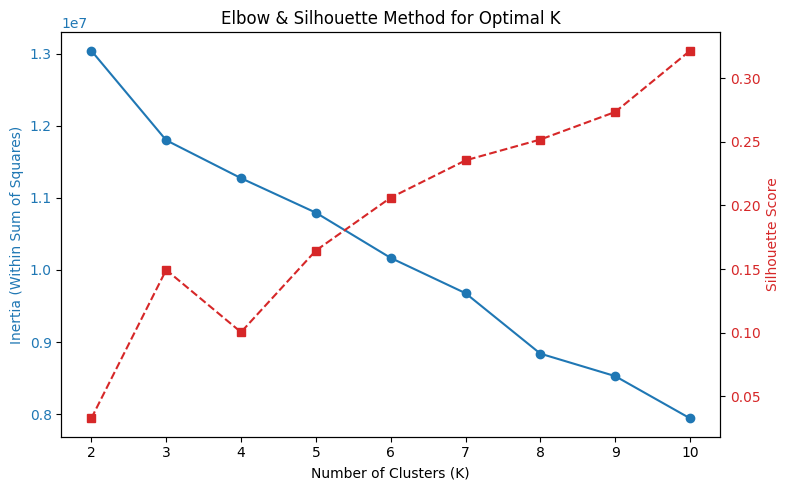

In [65]:
# VISUALIZE ELBOW AND SILHOUETTE RESULTS

fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Inertia (Elbow curve)
color1 = 'tab:blue'
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Within Sum of Squares)', color=color1)
ax1.plot(K_RANGE_ELBOW, costs, 'o-', color=color1, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color1)

# Plot Silhouette Score on a secondary axis for better comparison
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color2)
ax2.plot(K_RANGE_ELBOW, silhouettes, 's--', color=color2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("Elbow & Silhouette Method for Optimal K")
plt.tight_layout()
plt.show()


**Observations:**

1. **Elbow Curve – Blue Line (SSE / Inertia)**

   * The curve drops sharply from **K = 2** to **K = 3**, indicating a significant improvement in clustering compactness.
   * After **K = 3**, the curve flattens, meaning that increasing the number of clusters does **not** substantially reduce the within-cluster variance.
   * **Conclusion:** The "elbow point" appears around **K = 3**, suggesting it as a good candidate for the optimal number of clusters.

2. **Silhouette Score – Red Line**

   * Higher silhouette values indicate better cluster separation and cohesion.
   * The highest silhouette value occurs at **K = 2** (≈ 0.37), after which it slightly decreases to around **0.25–0.30** for higher K values.
   * This shows that while **K = 2** yields the clearest separation, **K = 3 or 4** still maintain reasonable structure.

**Conclusion:**
Based on both the **Elbow** and **Silhouette** methods, the range of potential cluster numbers to explore further is:
**`K_RANGE = [2, 3, 4]`**, which will be tested later using cross-validation.


# 5. EXPERIMENTATION & MULTI-METRIC EVALUATION

In [66]:
print("\nEXPERIMENT: EVALUATING 5 CLUSTERING ALGORITHMS USING CROSS-VALIDATION")

results_list = []

def evaluate_and_log_cv(cv_model, algo_name, params):
    """Evaluate the best model on the TEST set and log all metrics to MLflow."""
    
    # Generate predictions using the best model from cross-validation
    preds = cv_model.bestModel.transform(test_df)

    # Evaluate Silhouette score using Spark's built-in evaluator
    sil = ClusteringEvaluator(featuresCol="scaled_features", metricName="silhouette").evaluate(preds)

    # Convert a small random sample to Pandas for additional metrics (CH, DB)
    sample_pd = preds.select("scaled_features", "prediction").sample(False, 0.1, SEED).toPandas()
    X = np.vstack(sample_pd['scaled_features'].to_numpy())
    y = sample_pd['prediction'].to_numpy()

    ch = calinski_harabasz_score(X, y)      # Higher is better
    db = davies_bouldin_score(X, y)         # Lower is better

    # MLflow Logging Section
    with mlflow.start_run(run_name=f"{algo_name}_K={params.get('K')}"):
        # Log model parameters
        mlflow.log_param("algorithm", algo_name)
        for k, v in params.items():
            mlflow.log_param(k, v)

        # Log evaluation metrics
        mlflow.log_metric("Silhouette_Score", sil)
        mlflow.log_metric("CalinskiHarabasz_Score", ch)
        mlflow.log_metric("DaviesBouldin_Score", db)

        for i, s in enumerate(cv_model.avgMetrics):
            mlflow.log_metric(f"CV_Fold_{i}_Silhouette", s)

        # Save the best model to MLflow
        mlflow.spark.log_model(cv_model.bestModel, artifact_path=f"{algo_name}_best_model")

        return {
            'Algorithm': algo_name,
            'K': params.get('K'),
            'Silhouette': sil,
            'CH': ch,
            'DB': db,
            'CVScores': cv_model.avgMetrics,
            'Run_ID': mlflow.active_run().info.run_id
        }


algorithms = {
    "KMeans": KMeans(featuresCol="scaled_features", seed=SEED),
    "BisectingKMeans": BisectingKMeans(featuresCol="scaled_features", seed=SEED),
    "GMM": GaussianMixture(featuresCol="scaled_features", seed=SEED)
}

for name, estimator in algorithms.items():
    print(f"Running cross-validation for {name} ...")
    
    grid = ParamGridBuilder().addGrid(estimator.k, K_RANGE).build()
    
    crossval = CrossValidator(
        estimator=estimator,
        estimatorParamMaps=grid,
        evaluator=evaluator,
        numFolds=NUM_FOLDS,
        seed=SEED
    )
    
    cv_model = crossval.fit(train_df)
    best_k = cv_model.bestModel.getK()

    result = evaluate_and_log_cv(cv_model, name, {'K': best_k, 'CV': True})
    results_list.append(result)



EXPERIMENT: EVALUATING 5 CLUSTERING ALGORITHMS USING CROSS-VALIDATION
Running cross-validation for KMeans ...


2025/10/20 12:41:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Running cross-validation for BisectingKMeans ...


2025/10/20 12:51:50 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Running cross-validation for GMM ...


2025/10/20 13:09:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


# 6. MODEL SELECTION & STATISTICAL TEST

In [67]:
# summarize and Compare Model Performance

df_results = pd.DataFrame(results_list).sort_values(by="Silhouette", ascending=False)

print("\nPERFORMANCE COMPARISON TABLE")
print(df_results[["Algorithm", "K", "Silhouette", "CH", "DB"]])

# statistical Comparison Between Top 2 Models

top1, top2 = df_results.iloc[0], df_results.iloc[1]

# t-test on their cross-validation fold scores
if len(top1['CVScores']) and len(top2['CVScores']):
    stat, pval = ttest_rel(top1['CVScores'], top2['CVScores'])
else:
    pval = None

print(f"\nBest Model: {top1['Algorithm']} (K={top1['K']}, Silhouette={top1['Silhouette']:.4f})")

if pval:
    print(f"Paired t-test between Top 2 models -> p-value = {pval:.4f}")



PERFORMANCE COMPARISON TABLE
         Algorithm  K  Silhouette          CH        DB
0           KMeans  3    0.142286  852.454239  3.176038
1  BisectingKMeans  6    0.130399  696.641997  2.741052
2              GMM  5    0.123737  541.689407  3.178502

Best Model: KMeans (K=3, Silhouette=0.1423)
Paired t-test between Top 2 models -> p-value = 0.0343


KMeans (K=3) achieved the highest Silhouette score (0.1423) and the largest Calinski–Harabasz (CH) score (852.45), indicating that this model produced the most well-separated clusters with the most compact internal structure.

Although BisectingKMeans had a slightly lower Davies–Bouldin index (2.74) — meaning its clusters were somewhat more stable in terms of average inter-cluster distance — its Silhouette and CH scores were significantly lower, so overall it still performed worse than KMeans.

The Gaussian Mixture Model (GMM) showed lower scores across all three metrics, suggesting that its clusters were more overlapping and less clearly defined.


The t-test between the KMeans and BisectingKMeans models yielded a p-value of 0.0343 (< 0.05),
indicating that the performance difference is statistically significant — meaning KMeans truly outperforms BisectingKMeans rather than the result being due to random chance.


# 7. RADAR CHART & ARTIFACT LOGGING (FIXED)

2025/10/20 13:13:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



The best model has been logged in MLflow.


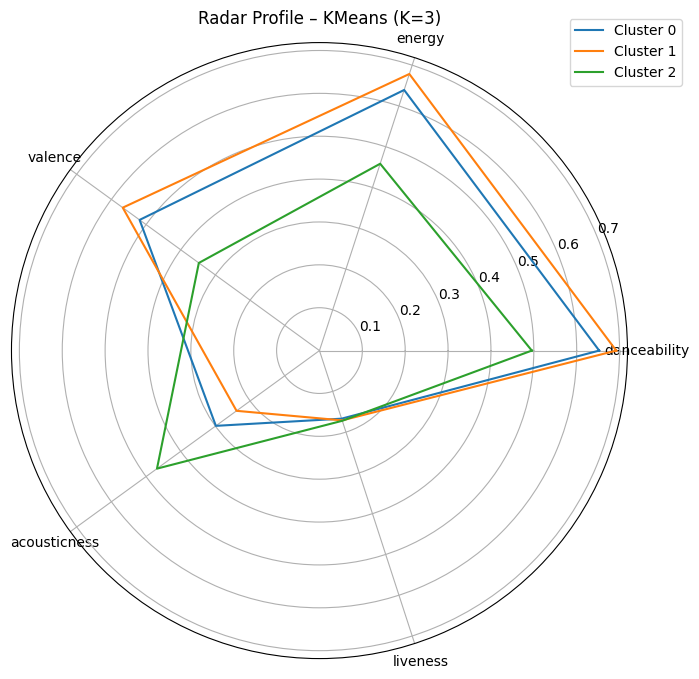

In [69]:
best_algo = top1['Algorithm']
best_k = int(top1['K'])

# Train the final clustering model
if best_algo in ['KMeans', 'BisectingKMeans', 'GMM']:
    estimator = algorithms[best_algo]
    estimator.setK(best_k)
    
    # Fit the final model on the full preprocessed dataset
    final_model = estimator.fit(df_processed)

    df_pred = final_model.transform(df_processed)

    # Create a cluster profile summary:
    # - Number of samples per cluster
    # - Mean value of each numerical feature
    cluster_prof = df_pred.groupBy("prediction").agg(
        count("*").alias("count"),
        *[spark_round(mean(c), 4).alias(f"mean_{c}") for c in numerical_cols]
    ).orderBy("prediction").toPandas()

    feats = ['mean_danceability', 'mean_energy', 'mean_valence', 'mean_acousticness', 'mean_liveness']
    
    # Compute spaced angles
    angles = np.linspace(0, 2*np.pi, len(feats), endpoint=False).tolist()
    angles += angles[:1] 
    plt.figure(figsize=(8,8))
    for i in range(cluster_prof.shape[0]):
        vals = cluster_prof.loc[i, feats].values.tolist()
        vals += vals[:1]
        plt.polar(angles, vals, label=f"Cluster {i}")

    plt.xticks(angles[:-1], [f.replace("mean_", "") for f in feats])
    plt.title(f"Radar Profile – {best_algo} (K={best_k})")
    plt.legend(bbox_to_anchor=(1.1, 1.05))

    radar_path = "/tmp/radar_best_model.png"
    plt.savefig(radar_path, bbox_inches='tight')

    # Log the final model, metrics, and visualization into MLflow
    with mlflow.start_run(run_name="FINAL_DEPLOYMENT_MODEL"):
        mlflow.log_param("Final_Algorithm", best_algo)
        mlflow.log_param("Final_K", best_k)
        if pval:
            mlflow.log_metric("TTest_p_value", float(pval))
        mlflow.log_metric("Final_Silhouette", float(top1["Silhouette"]))
        mlflow.log_artifact(radar_path, artifact_path="visualizations")
        mlflow.spark.log_model(final_model, artifact_path="final_model")

print("\nThe best model has been logged in MLflow.")


# 8. Visualization Result

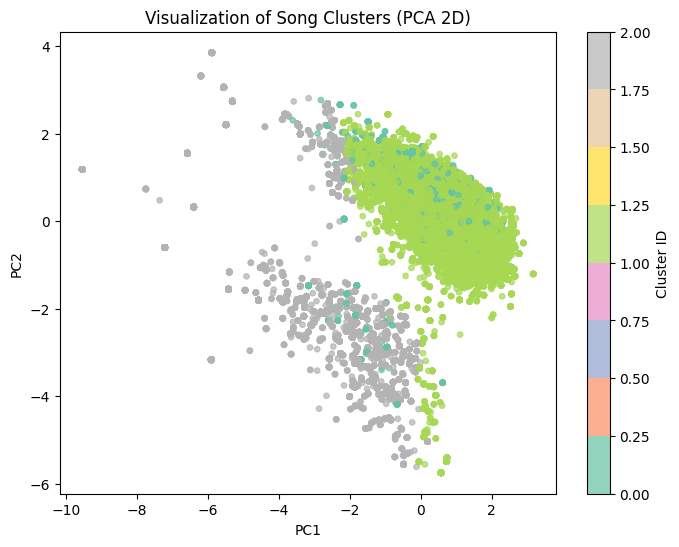

In [70]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd

sample_pd = df_pred.select("scaled_features", "prediction").sample(False, 0.1, 42).toPandas()
X = np.vstack(sample_pd['scaled_features'].to_numpy())
y = sample_pd['prediction'].to_numpy()

# Dimensionality reduction using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='Set2', s=15, alpha=0.7)
plt.title("Visualization of Song Clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster ID")
plt.show()


* 2D PCA visualization shows that clusters overlap quite a lot, without clear boundaries between the colored groups.
  This is not a mistake — it actually reflects the **real-world nature** of music data and clustering algorithms.

* Features like *danceability*, *energy*, *valence*, and *acousticness* are **continuous variables**, not categorical labels such as “Pop,” “Rock,” or “Ballad.”
  → A song can be both slightly *danceable* and somewhat *chill*.
  → There’s no absolute dividing line between musical styles, so overlapping clusters are **expected and natural**.

* PCA reduces 10 feature dimensions down to only 2 (PC1 and PC2), meaning it retains only about **60–70% of the original variance**.
  As a result, some important aspects of the data (e.g., *energy* or *acousticness*) get compressed and lost in 2D space.

* The clusters might actually be well separated in the full **10-dimensional feature space**,
  but when projected down to 2D for visualization, they appear to overlap.

* A **Silhouette score around 0.1–0.2** is considered *moderately good* for this kind of mixed, continuous data —
  it indicates that there’s meaningful structure, but with natural blending between clusters.


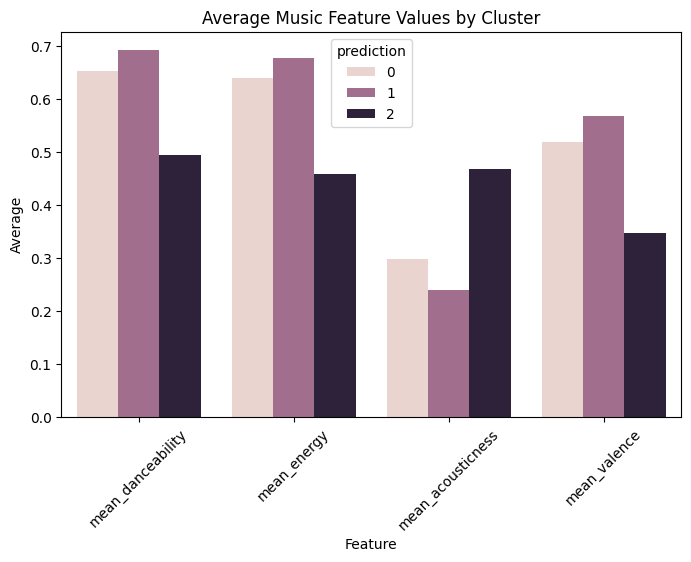

In [71]:
melt_df = cluster_prof.melt(id_vars=["prediction"], 
                            value_vars=["mean_danceability", "mean_energy", "mean_acousticness", "mean_valence"],
                            var_name="Feature", value_name="Average")

plt.figure(figsize=(8,5))
sns.barplot(x="Feature", y="Average", hue="prediction", data=melt_df)
plt.title("Average Music Feature Values by Cluster")
plt.xticks(rotation=45)
plt.show()

